# STN CAPAG Municípios — extraction and cleaning, release 2026-06-01

Extracts a tidy municipal table (published CAPAG, ICF, indicators and a derived, versioned credit screen) from the June 2026 Prévia da CAPAG workbook.

- **Source:** [Tesouro Transparente, capag-municipios](https://www.tesourotransparente.gov.br/ckan/dataset/capag-municipios) (raw XLSX in `sample/`, re-download steps in the review README)
- **Review:** `../../README.md` · release `2026-06-01`
- Each cleaning block implements one parsing note from the review README.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from openpyxl import load_workbook

RAW = "sample/capag-municipios-posicao-2026-jun.xlsx"
OUT = "data/br_capag_municipios_clean.csv"
RESULT_SHEET = "Prévia da CAPAG"
HEADER_ROW = 3  # 1-based; data rows start on row 4

FAVOURABLE = ["A", "A+", "B", "B+"]
ICF_FAIL = ["Dicf", "Eicf"]
SCREEN_RULE = "capag-icf-2026-06"  # published CAPAG + Dicf/Eicf ineligibility effective 2026

# Known source-side defects, asserted by name in validation
CALCOENE = "1600204"            # single all-#N/A row in the result sheet
MISSING_FROM_RESULT = "5101837" # in the internal Datalake sheet, absent from the result

## 1. Load raw

In [2]:
# Result sheet only: headers on row 3, data from row 4 — rows 1-2 hold lookup
# formulas and working labels and must not be parsed as records (parsing note).
# Read-only streaming keeps the formula-heavy workbook manageable, and reading
# cached values through openpyxl (not pandas.read_excel) preserves the literal
# #N/A error tokens that pandas' default NA filter would silently blank
# (parsing note on sentinels).
wb = load_workbook(RAW, read_only=True, data_only=True)
ws = wb[RESULT_SHEET]
rows = ws.iter_rows(min_row=HEADER_ROW, values_only=True)
header = next(rows)
raw = pd.DataFrame((r for r in rows if r[0] is not None), columns=header)
wb.close()
print(f"raw shape: {raw.shape}")
raw.head(3)

raw shape: (5568, 22)


,Código Município Completo,Nome_Município,UF,CAPAG,Indicador 1,Nota 1,Indicador 2,Nota 2,Indicador 3,Nota 3,...,Origem da Nota Final,Possui DCA 2025?,Indicador 3 Antigo,Possui DCA 2024?,CAPAG rebaixada,Dedução Negativa,DCB zerada ou negativa,OF negativa,Publicou RGF,Publicou RREO
0,1100015,Alta Floresta D'Oeste,RO,C,0.044334,A,0.971625,C,0,C,...,CAPAG Ano Base 2025,Sim,n.d.,Sim,None,NaN,NaN,NaN,Sim,Sim
1,1100023,Ariquemes,RO,B+,0.108558,A,0.882288,B,0.019131,B,...,CAPAG Ano Base 2025,Sim,0.199714,Sim,None,NaN,NaN,NaN,Sim,Sim
2,1100031,Cabixi,RO,A,0.000048,A,0.900374,B,0.142274,A,...,CAPAG Ano Base 2025,Sim,0.13439,Sim,None,NaN,NaN,NaN,Sim,Sim


## 2. Clean

In [3]:
# The result sheet mixes the published result with workbook-internal working
# columns (availability checks, a prior-method indicator, an empty downgrade
# flag); keep the published result columns, renamed to snake_case
# (parsing note on working columns).
keep = {
    "Código Município Completo": "municipality_code",
    "Nome_Município": "municipality_name",
    "UF": "uf",
    "CAPAG": "capag",
    "ICF": "icf",
    "Indicador 1": "indicator_debt",
    "Nota 1": "grade_debt",
    "Indicador 2": "indicator_savings",
    "Nota 2": "grade_savings",
    "Indicador 3": "indicator_liquidity",
    "Nota 3": "grade_liquidity",
    "Observação": "observation",
    "Origem da Nota Final": "final_grade_origin",
}
df = raw[list(keep)].rename(columns=keep)
df.head(3)

,municipality_code,municipality_name,uf,capag,icf,indicator_debt,grade_debt,indicator_savings,grade_savings,indicator_liquidity,grade_liquidity,observation,final_grade_origin
0,1100015,Alta Floresta D'Oeste,RO,C,Cicf,0.044334,A,0.971625,C,0,C,NaN,CAPAG Ano Base 2025
1,1100023,Ariquemes,RO,B+,Aicf,0.108558,A,0.882288,B,0.019131,B,NaN,CAPAG Ano Base 2025
2,1100031,Cabixi,RO,A,Bicf,0.000048,A,0.900374,B,0.142274,A,NaN,CAPAG Ano Base 2025


In [4]:
# The municipality code is stored as a number but is an identifier: emit it as
# a seven-character string; names are not unique nationally and are never join
# keys (parsing note).
df["municipality_code"] = df["municipality_code"].astype(int).astype(str)
assert df["municipality_code"].str.len().eq(7).all()
df[["municipality_code", "municipality_name", "uf"]].head(3)

,municipality_code,municipality_name,uf
0,1100015,Alta Floresta D'Oeste,RO
1,1100023,Ariquemes,RO
2,1100031,Cabixi,RO


In [5]:
# The indicator columns mix numeric fractions with the text sentinel n.d. and
# the Excel error token #N/A: coercion must separate measurements from status
# values instead of collapsing both to blank (parsing note).
for col in ["indicator_debt", "indicator_savings", "indicator_liquidity"]:
    numeric = pd.to_numeric(df[col], errors="coerce")
    df[col + "_status"] = df[col].where(numeric.isna(), "ok")
    df[col] = numeric
df.filter(like="_status").apply(lambda s: s.value_counts()).T.fillna(0).astype(int)

,ok,n.d.,#N/A
indicator_debt_status,5443,124,1
indicator_savings_status,5233,334,1
indicator_liquidity_status,5028,539,1


In [6]:
# Observation text carries embedded line breaks where more than one issue
# applies: keep the wording, flatten the breaks to a separator so the CSV stays
# one line per municipality (parsing note). Calçoene's observation cell is the
# #N/A error token, not explanatory text — treated as absent, its state is
# carried by the capag and status columns.
df["observation"] = (
    df["observation"]
    .replace("#N/A", pd.NA)
    .str.strip()
    .str.replace("\n", " | ", regex=False)
)
print(f"observations kept: {df.observation.notna().sum()} municipalities")

observations kept: 810 municipalities


In [7]:
# Every published row states fiscal base year 2025 through its final-grade
# origin; the release date and the fiscal base year are separate fields and
# both are preserved (README scope note).
assert (df["final_grade_origin"] == "CAPAG Ano Base 2025").all()
df["fiscal_base_year"] = 2025
df["release_date"] = "2026-06-01"
df = df.drop(columns="final_grade_origin")
df[["municipality_code", "capag", "icf", "fiscal_base_year", "release_date"]].head(3)

,municipality_code,capag,icf,fiscal_base_year,release_date
0,1100015,C,Cicf,2025,2026-06-01
1,1100023,B+,Aicf,2025,2026-06-01
2,1100031,A,Bicf,2025,2026-06-01


In [8]:
# The published CAPAG column alone misclassifies Dicf municipalities under the
# rule effective in 2026, so the eligibility screen is derived from CAPAG and
# ICF together, under an explicitly versioned rule (interpretation warning;
# derived states defined in the review README).
def screen(row):
    if row.icf in ICF_FAIL:
        return "credit_screen_fail_information_quality"
    if row.capag in FAVOURABLE:
        return "credit_screen_pass"
    if row.capag in ("C", "D"):
        return "credit_screen_fail_fiscal"
    return "credit_screen_unknown"

df["credit_screen"] = df.apply(screen, axis=1)
df["credit_screen_rule"] = SCREEN_RULE
df["credit_screen"].value_counts()

credit_screen
credit_screen_pass                        2358
credit_screen_fail_fiscal                 1984
credit_screen_fail_information_quality     674
credit_screen_unknown                      552
Name: count, dtype: int64

## 3. Validate

Assertions against the workbook facts recorded in the review README — if any fail, the cleaning is wrong; do not export. Consistency checks that flag rather than fail come after the hard assertions.

In [9]:
# Structure: full published coverage, unique 7-digit codes, no null identifiers
assert len(df) == 5568, len(df)
assert df.municipality_code.is_unique
assert df[["municipality_code", "municipality_name", "uf", "capag", "icf"]].notna().all().all()
assert df.uf.nunique() == 26

# Published grade distributions match the README's workbook cross-checks
assert df.capag.value_counts().to_dict() == {
    "C": 2184, "A": 1190, "B": 976, "n.d.": 683, "A+": 265,
    "n.e.": 137, "B+": 113, "D": 19, "#N/A": 1}
assert df.icf.value_counts().to_dict() == {
    "Bicf": 2754, "Cicf": 1537, "Aicf": 603, "Dicf": 537, "Eicf": 137}

# The 2026 rule conflict the README documents: favourable letters on Dicf rows
dicf_fav = df[(df.icf == "Dicf") & df.capag.isin(FAVOURABLE)]
assert len(dicf_fav) == 186
assert dicf_fav.capag.value_counts().to_dict() == {"A": 103, "B": 83}

# Derived screen reproduces the README's screening groups
assert df.credit_screen.value_counts().to_dict() == {
    "credit_screen_pass": 2358,
    "credit_screen_fail_fiscal": 1984,
    "credit_screen_fail_information_quality": 674,
    "credit_screen_unknown": 552}

# Known source-side defects, asserted by name — never silently absorbed
calc = df[df.municipality_code == CALCOENE]
assert calc.capag.iloc[0] == "#N/A"
assert (calc.filter(like="_status") == "#N/A").all().all()
assert MISSING_FROM_RESULT not in set(df.municipality_code)

# Observation text: 810 municipalities with explanatory wording
assert df.observation.notna().sum() == 810

print("all hard validations passed")

all hard validations passed


In [10]:
# Consistency check (flag, not failure): can each grade be reproduced from its
# displayed indicator via the published thresholds? Debt and liquidity
# reproduce exactly; the savings grade does not — it reflects the three-
# exercise weighted calculation, while the displayed value is a single
# exercise. Downstream must use the grade columns, never re-derive them.
def check(vals, grades, fn):
    mask = vals.notna() & grades.isin(["A", "B", "C"])
    return mask.sum(), (vals[mask].map(fn) != grades[mask]).sum()

n1, m1 = check(df.indicator_debt, df.grade_debt,
               lambda v: "A" if v < 0.6 else ("B" if v < 1.0 else "C"))
n2, m2 = check(df.indicator_savings, df.grade_savings,
               lambda v: "A" if v < 0.85 else ("B" if v < 0.95 else "C"))
n3, m3 = check(df.indicator_liquidity, df.grade_liquidity,
               lambda v: "A" if v >= 0.05 else ("B" if v > 0 else "C"))
assert m1 == 0 and m3 == 0, (m1, m3)
print(f"debt: {n1} checked, {m1} mismatches — reproduces exactly")
print(f"liquidity: {n3} checked, {m3} mismatches — reproduces exactly")
print(f"savings: {n2} checked, {m2} mismatches — FLAG: grade is not a function "
      "of the displayed indicator (three-exercise weighting)")

# Plausibility flag: a handful of savings ratios are implausible reporting
# artifacts (declared-negative source items in most cases); none of these
# rows reaches a letter grade — all are n.d. or n.e.
extreme = df[(df.indicator_savings > 2) | (df.indicator_savings < 0)]
assert len(extreme) == 7
assert extreme.capag.isin(["n.d.", "n.e."]).all()
assert extreme.observation.notna().sum() == 5
extreme[["municipality_code", "municipality_name", "uf", "capag",
         "indicator_savings"]].sort_values("indicator_savings", ascending=False)

debt: 5443 checked, 0 mismatches — reproduces exactly
liquidity: 5028 checked, 0 mismatches — reproduces exactly
savings: 5126 checked, 1026 mismatches — FLAG: grade is not a function of the displayed indicator (three-exercise weighting)


,municipality_code,municipality_name,uf,capag,indicator_savings
58,1200252,Epitaciolândia,AC,n.d.,28123.398514
2439,3117876,Confins,MG,n.d.,511.654629
2264,3102050,Alto Caparaó,MG,n.d.,19.330198
2300,3105301,Bandeira do Sul,MG,n.d.,6.753701
4511,4213351,Ponte Alta do Norte,SC,n.d.,-0.882885
971,2305803,Ipu,CE,n.e.,-1.175373
1935,2909109,Coribe,BA,n.d.,-1.766214


## 4. Export

In [11]:
df.to_csv(OUT, index=False)
print(f"wrote {OUT}: {len(df)} rows x {df.shape[1]} columns")
df.head(3)

wrote data/br_capag_municipios_clean.csv: 5568 rows x 19 columns

,municipality_code,municipality_name,uf,capag,icf,indicator_debt,grade_debt,indicator_savings,grade_savings,indicator_liquidity,grade_liquidity,observation,indicator_debt_status,indicator_savings_status,indicator_liquidity_status,fiscal_base_year,release_date,credit_screen,credit_screen_rule
0,1100015,Alta Floresta D'Oeste,RO,C,Cicf,0.044334,A,0.971625,C,0.000000,C,NaN,ok,ok,ok,2025,2026-06-01,credit_screen_fail_fiscal,capag-icf-2026-06
1,1100023,Ariquemes,RO,B+,Aicf,0.108558,A,0.882288,B,0.019131,B,NaN,ok,ok,ok,2025,2026-06-01,credit_screen_pass,capag-icf-2026-06
2,1100031,Cabixi,RO,A,Bicf,0.000048,A,0.900374,B,0.142274,A,NaN,ok,ok,ok,2025,2026-06-01,credit_screen_pass,capag-icf-2026-06


## 5. Fit analysis

Limited to the questions the finance-feasibility need raises: what the derived credit screen yields nationally, how it distributes geographically, and the size of the published-grade vs eligibility-rule conflict.

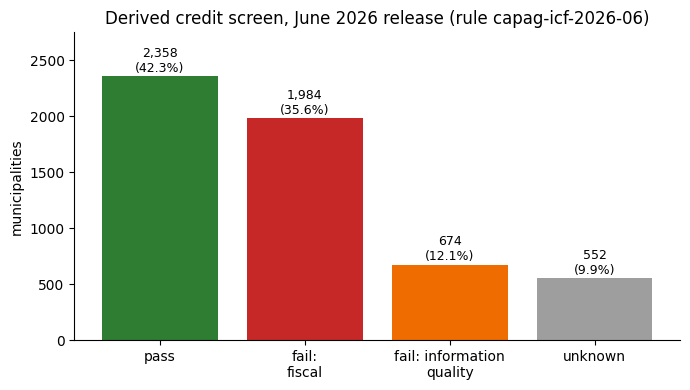

In [12]:
# 5.1 What the June 2026 release yields under the versioned screen
order = ["credit_screen_pass", "credit_screen_fail_fiscal",
         "credit_screen_fail_information_quality", "credit_screen_unknown"]
labels = ["pass", "fail:\nfiscal", "fail: information\nquality", "unknown"]
counts = df.credit_screen.value_counts().reindex(order)
colors = ["#2e7d32", "#c62828", "#ef6c00", "#9e9e9e"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, counts.values, color=colors)
for bar, n in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, n + 40,
            f"{n:,}\n({n / len(df):.1%})", ha="center", fontsize=9)
ax.set_ylim(0, 2750)
ax.set_ylabel("municipalities")
ax.set_title("Derived credit screen, June 2026 release (rule capag-icf-2026-06)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

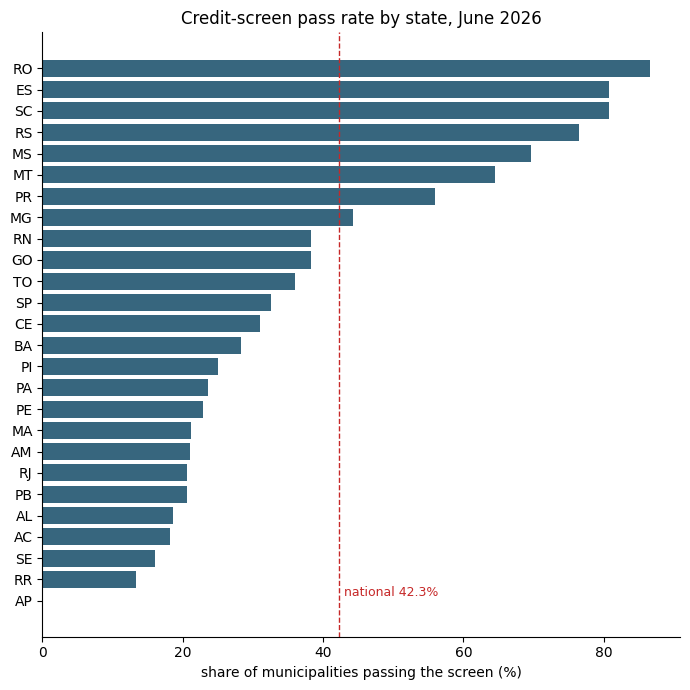

In [13]:
# 5.2 Geography of the screen: pass rate by state
by_uf = (df.assign(passed=df.credit_screen == "credit_screen_pass")
           .groupby("uf").passed.mean().sort_values())
fig, ax = plt.subplots(figsize=(7, 7))
ax.barh(by_uf.index, by_uf.values * 100, color="#37667e")
ax.axvline(42.3, color="#c62828", linewidth=1, linestyle="--")
ax.text(43, 0.2, "national 42.3%", color="#c62828", fontsize=9)
ax.set_xlabel("share of municipalities passing the screen (%)")
ax.set_title("Credit-screen pass rate by state, June 2026")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [14]:
# 5.3 The published-grade vs eligibility-rule conflict, quantified:
# distribution of the published CAPAG within each ICF grade. The Dicf row
# shows the 186 favourable-looking municipalities (103 A + 83 B) that the
# 2026 rule makes ineligible despite their displayed letter.
xt = pd.crosstab(df.icf, df.capag).reindex(
    ["Aicf", "Bicf", "Cicf", "Dicf", "Eicf"])[
    ["A+", "A", "B+", "B", "C", "D", "n.d.", "n.e.", "#N/A"]]
xt["favourable"] = xt[["A+", "A", "B+", "B"]].sum(axis=1)
xt

capag,A+,A,B+,B,C,D,n.d.,n.e.,#N/A,favourable
icf,,,,,,,,,,
Aicf,265,0,113,0,211,1,13,0,0,378
Bicf,0,774,0,563,1150,8,259,0,0,1337
Cicf,0,313,0,330,605,9,279,0,1,643
Dicf,0,103,0,83,218,1,132,0,0,186
Eicf,0,0,0,0,0,0,0,137,0,0


## Findings

**Extraction**

- All hard validations pass: 5,568 unique seven-digit municipality codes across 26 states, grade distributions and the four derived screening groups (2,358 / 1,984 / 674 / 552) match the review README exactly, and the two named source defects (Calçoene's all-#N/A row, code 5101837 absent from the result sheet) reproduce.
- The savings grade cannot be re-derived from the displayed savings indicator: 1,026 of 5,126 checkable rows mismatch the published thresholds, while the debt and liquidity grades reproduce exactly (0 mismatches). The displayed savings value is a single-exercise figure; the grade reflects the three-exercise weighted calculation held in other sheets. Flowed back into the README as a parsing note: use the grade columns, never recompute them.
- Seven municipalities carry implausible savings ratios (from −1.77 up to 28,123, reporting artifacts mostly from declared-negative source items); five of the seven carry an explanatory observation and every one lands on `n.d.` or `n.e.` rather than a letter grade. Flowed back into the README as an interpretation warning: raw indicator values are not bounded and must not feed averages or scores unfiltered.
- The `CAPAG rebaixada` (downgrade) working column is entirely empty in this release — dropped from the tidy output.
- Observation text: 810 municipalities (the README's earlier count of 811 included Calçoene's #N/A error token); 673 carry multiple issues flattened to a `|` separator.

**Fit (finance-feasibility screen)**

- The versioned screen passes 2,358 municipalities (42.3%). Information-quality failure takes precedence over the displayed letter for 186 favourable-looking Dicf municipalities — the conflict the README documents, quantified in §5.3.
- The screen has a strong geographic gradient: pass rates run from 87% (RO) and 81% (ES, SC) down to 13% (RR) and 0% (AP, 0 of 16). Feasibility outputs for North and Northeast cities will lean heavily on non-guaranteed routes, which this dataset does not gate.
- The derived states are screening groups, not credit approvals; the rule string `capag-icf-2026-06` is stamped on every row so later releases can carry a different rule without ambiguity.